# Hazard CONUS Grid - Hail M0 - Selected Pilot-Cell Lock

**Peril:** hail - **Layer:** M0/M1 pilot setup - **Product:** `hazard_conus_grid`

This notebook turns reviewed candidate cells into the **selected-cell manifest** consumed by the hail M1
pilot.

## Step back - what is this lock?

We are not locking a production hail model. We are locking the **four cells used to test the pipeline**:

```text
selected pilot cells
  -> selected-cell x date panel
  -> hail-day frequency distribution
  -> hail-size distribution
  -> asset damage/loss for canonical grid asset
  -> EAL / VaR / PML / TVaR smoke test
```

This lock exists because the next notebook should consume a clean, unambiguous input list instead of
guessing from candidate or QA files.

**Allowed use:** run the selected-cell M1 pilot.

**Not allowed:** treat these four cells as a final CONUS hail map, final production climatology, or final
reportable risk output.

Source chain:

```text
01 MRMS daily MESH notebook
  -> candidate cells from bounded Apr-Jun 2024 MRMS evidence

03 Storm Events / NRI QA notebook
  -> report-side sanity check; all four candidates kept

04 this notebook
  -> selected_pilot_cells_v2026_06_16.csv/json
```

Plan links:

- [`docs/plans/hazard_conus_grid/hail/pilot_cell_selection.md`](../../../../../docs/plans/hazard_conus_grid/hail/pilot_cell_selection.md)
- [`docs/plans/hazard_conus_grid/hail/pilot.md`](../../../../../docs/plans/hazard_conus_grid/hail/pilot.md)
- [`docs/plans/hazard_conus_grid/hail/m0_m1_hazard_layer.md`](../../../../../docs/plans/hazard_conus_grid/hail/m0_m1_hazard_layer.md)

In [1]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

plt.rcParams.update({"axes.grid": True, "grid.alpha": 0.3, "figure.dpi": 110})


def _repo_root() -> Path:
    for p in [Path.cwd(), *Path.cwd().parents]:
        if (p / "AGENTS.md").exists():
            return p
    raise FileNotFoundError("repo root not found")


ROOT = _repo_root()
HAIL_GRID_DIR = ROOT / "data" / "hazard_conus_grid" / "hail"
GRID_DIR = ROOT / "data" / "hazard_conus_grid" / "common" / "benchmark_grid"

CANDIDATE_CSV = HAIL_GRID_DIR / "pilot_cell_candidates_mrms_202404_202406.csv"
QA_CSV = HAIL_GRID_DIR / "pilot_cell_report_qa_hydronos_1996_2024.csv"
SERVED_MASK_CSV = GRID_DIR / "served_conus_cell_ids_v2026_06.csv"

SELECTION_VERSION = "v2026_06_16"
SELECTED_CSV = HAIL_GRID_DIR / f"selected_pilot_cells_{SELECTION_VERSION}.csv"
SELECTED_JSON = HAIL_GRID_DIR / f"selected_pilot_cells_{SELECTION_VERSION}.json"
WRITE_SELECTED_MANIFEST = True

REQUIRED_ROLES = ["high_hail", "medium_hail", "low_hail", "hayhurst_reference"]
MRMS_SELECTION_WINDOW = "2024-04-01 to 2024-06-30"
NOAA_REPORT_WINDOW = "1996-01-01 to 2024-12-31"

print("repo root:", ROOT)
print("candidate input:", CANDIDATE_CSV)
print("QA input:", QA_CSV)
print("served mask:", SERVED_MASK_CSV)
print("selected output:", SELECTED_CSV)

repo root: /Users/divy/code/work/infrasure_git_codes/Hazard_modeling
candidate input: /Users/divy/code/work/infrasure_git_codes/Hazard_modeling/data/hazard_conus_grid/hail/pilot_cell_candidates_mrms_202404_202406.csv
QA input: /Users/divy/code/work/infrasure_git_codes/Hazard_modeling/data/hazard_conus_grid/hail/pilot_cell_report_qa_hydronos_1996_2024.csv
served mask: /Users/divy/code/work/infrasure_git_codes/Hazard_modeling/data/hazard_conus_grid/common/benchmark_grid/served_conus_cell_ids_v2026_06.csv
selected output: /Users/divy/code/work/infrasure_git_codes/Hazard_modeling/data/hazard_conus_grid/hail/selected_pilot_cells_v2026_06_16.csv


## 1 - Load candidate, QA, and served-mask inputs

These are the only inputs allowed for the lock. No legacy model outputs or unexplained delivery files are
part of this decision.

In [2]:
candidates = pd.read_csv(CANDIDATE_CSV)
qa = pd.read_csv(QA_CSV)
served = pd.read_csv(SERVED_MASK_CSV)

display(candidates[["role", "cell_id", "lat_center", "lon_center", "n_hail_days", "mesh_max_mm"]])
display(qa[["role", "cell_id", "qa_recommendation", "qa_status", "remaining_before_final_lock"]])

,role,cell_id,lat_center,lon_center,n_hail_days,mesh_max_mm
0,high_hail,329354,33.00,-101.50,12,105.800003
1,medium_hail,261700,44.75,-95.00,2,37.299999
2,low_hail,247197,47.25,-120.75,0,NaN
3,hayhurst_reference,336544,31.75,-104.00,2,33.299999


,role,cell_id,qa_recommendation,qa_status,remaining_before_final_lock
0,high_hail,329354,keep_candidate_pending_spc_map_review,candidate_report_qa_complete_not_final_lock,SPC/map review and broad climatology check
1,medium_hail,261700,keep_body_case_pending_spc_map_review,candidate_report_qa_complete_not_final_lock,SPC/map review and broad climatology check
2,low_hail,247197,keep_low_control_pending_spc_map_review,candidate_report_qa_complete_not_final_lock,SPC/map review and broad climatology check
3,hayhurst_reference,336544,keep_reference_pending_spc_map_review,candidate_report_qa_complete_not_final_lock,SPC/map review and broad climatology check


**Takeaway.** The selected manifest is derived from the MRMS candidate file plus the NOAA/NRI QA file. The
served mask is used only to prove every selected `cell_id` is a valid benchmark cell.

## 2 - Acceptance checks

The notebook stops if any of these fail:

- exactly the four expected roles are present;
- no duplicate selected `cell_id`;
- every cell joins to the served CONUS mask;
- every row has a keep-style QA recommendation;
- the low-control candidate still has zero MRMS severe-hail days in the bounded window.

In [3]:
errors: list[str] = []

candidate_roles = candidates["role"].tolist()
qa_roles = qa["role"].tolist()

if sorted(candidate_roles) != sorted(REQUIRED_ROLES):
    errors.append(f"candidate roles mismatch: {candidate_roles}")
if sorted(qa_roles) != sorted(REQUIRED_ROLES):
    errors.append(f"QA roles mismatch: {qa_roles}")
if not candidates["cell_id"].is_unique:
    errors.append("candidate cell_id values are not unique")
if not qa["cell_id"].is_unique:
    errors.append("QA cell_id values are not unique")

joined = candidates.merge(served[["cell_id"]], on="cell_id", how="left", indicator=True)
if not joined["_merge"].eq("both").all():
    errors.append("one or more candidate cell_id values do not join to the served CONUS mask")

qa_keep = qa["qa_recommendation"].astype(str).str.startswith("keep_")
if not qa_keep.all():
    errors.append("one or more QA recommendations are not keep-style recommendations")

low = candidates.loc[candidates["role"].eq("low_hail")]
if low.empty or int(low.iloc[0]["n_hail_days"]) != 0:
    errors.append("low_hail candidate is missing or does not have zero MRMS hail days in the bounded window")

checks = pd.DataFrame(
    [
        ("expected roles present", sorted(candidate_roles) == sorted(REQUIRED_ROLES) and sorted(qa_roles) == sorted(REQUIRED_ROLES)),
        ("unique cell ids", candidates["cell_id"].is_unique and qa["cell_id"].is_unique),
        ("served mask join", joined["_merge"].eq("both").all()),
        ("QA keep recommendations", qa_keep.all()),
        ("low control has zero MRMS hail days", low.empty is False and int(low.iloc[0]["n_hail_days"]) == 0),
    ],
    columns=["check", "pass"],
)
checks

,check,pass
0,expected roles present,True
1,unique cell ids,True
2,served mask join,True
3,QA keep recommendations,True
4,low control has zero MRMS hail days,True


In [4]:
if errors:
    raise AssertionError("selected-cell lock failed:\n- " + "\n- ".join(errors))

print("all selected-cell lock checks passed")

all selected-cell lock checks passed


## 3 - Map / broad-climatology review

This is a lightweight final visual/role check, not a new source model. The goal is to confirm the cells are
geographically consistent with their pilot role:

- high: TX / High Plains hail-active corridor;
- medium: upper Midwest body-case / transition cell;
- low: WA quiet-control cell;
- Hayhurst: reference TX cell from the completed asset pipeline.

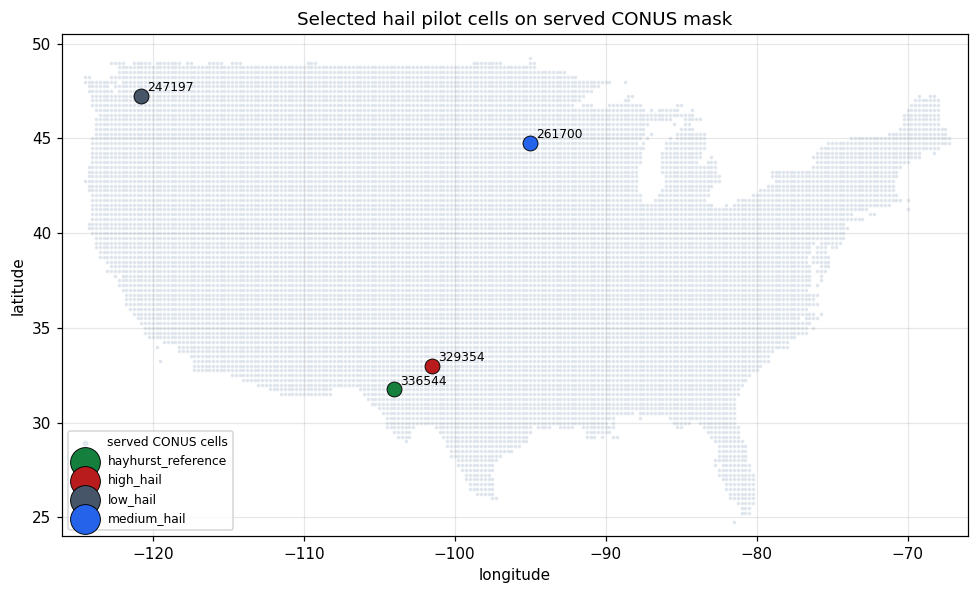

In [5]:
role_colors = {
    "high_hail": "#b91c1c",
    "medium_hail": "#2563eb",
    "low_hail": "#475569",
    "hayhurst_reference": "#15803d",
}

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.scatter(served["lon_center"], served["lat_center"], s=2, color="#cbd5e1", alpha=0.45, label="served CONUS cells")
for role, group in candidates.groupby("role"):
    ax.scatter(
        group["lon_center"],
        group["lat_center"],
        s=95,
        color=role_colors.get(role, "#111827"),
        edgecolor="black",
        linewidth=0.6,
        label=role,
        zorder=4,
    )
    for _, row in group.iterrows():
        ax.text(row["lon_center"] + 0.4, row["lat_center"] + 0.25, str(int(row["cell_id"])), fontsize=8)

ax.set(
    title="Selected hail pilot cells on served CONUS mask",
    xlabel="longitude",
    ylabel="latitude",
    xlim=(-126, -66),
    ylim=(24, 50.5),
)
ax.legend(markerscale=2, fontsize=8, loc="lower left")
plt.tight_layout()
plt.show()

In [6]:
climatology_review = pd.DataFrame(
    [
        (
            "high_hail",
            "passes",
            "TX High Plains / ERCOT-adjacent candidate with strong MRMS evidence, active NOAA reports, and Very High NRI hail rating.",
        ),
        (
            "medium_hail",
            "passes_with_role_note",
            "MN upper-Midwest candidate is report-active, but its MRMS bounded-window evidence is body-case; use it as medium by MRMS evidence, not by report count.",
        ),
        (
            "low_hail",
            "passes",
            "WA candidate has zero MRMS severe days in the bounded window, low report density, and Very Low NRI hail rating.",
        ),
        (
            "hayhurst_reference",
            "passes",
            "TX reference cell contains the completed Hayhurst solar asset and bridges back to the existing hail x solar notebooks.",
        ),
    ],
    columns=["role", "map_climatology_review_status", "map_climatology_review_note"],
)
climatology_review

,role,map_climatology_review_status,map_climatology_review_note
0,high_hail,passes,TX High Plains / ERCOT-adjacent candidate with...
1,medium_hail,passes_with_role_note,"MN upper-Midwest candidate is report-active, b..."
2,low_hail,passes,WA candidate has zero MRMS severe days in the ...
3,hayhurst_reference,passes,TX reference cell contains the completed Hayhu...


**Takeaway.** The map / broad-role review supports locking these four cells for the selected-cell M1 pilot.
The `medium_hail` role is intentionally based on MRMS bounded-window cell evidence; report counts within
25 miles are only a validation overlay and are not the role definition.

## 4 - Build the selected pilot-cell manifest

The output below is the only file the M1 pilot should read for selected cells. It carries both the source
evidence and the usage limits.

In [7]:
selected = (
    candidates.merge(
        qa[
            [
                "role",
                "cell_id",
                "noaa_reports_per_year",
                "noaa_mrms_window_reports",
                "noaa_mrms_window_report_days",
                "noaa_max_size_in",
                "noaa_p95_size_in",
                "hail_afreq",
                "hail_riskr",
                "qa_recommendation",
                "qa_reason",
            ]
        ],
        on=["role", "cell_id"],
        how="left",
    )
    .merge(climatology_review, on="role", how="left")
)

selected.insert(0, "hazard", "hail")
selected.insert(1, "selection_version", SELECTION_VERSION)
selected.insert(2, "selection_status", "selected_for_m1_pilot")
selected["allowed_use"] = "selected-cell M1 pilot only"
selected["not_allowed_use"] = "not production CONUS hail climatology; not final reportable risk"
selected["mrms_selection_window"] = MRMS_SELECTION_WINDOW
selected["noaa_report_window"] = NOAA_REPORT_WINDOW
selected["source_candidate_artifact"] = str(CANDIDATE_CSV.relative_to(ROOT))
selected["source_report_qa_artifact"] = str(QA_CSV.relative_to(ROOT))
selected["source_notebooks"] = (
    "Notebooks/hazard_conus_grid/hail/m0_input_data/01_mrms_daily_mesh/01_mrms_daily_mesh.ipynb; "
    "Notebooks/hazard_conus_grid/hail/m0_input_data/03_storm_events_anchor/01_candidate_report_qa.ipynb; "
    "Notebooks/hazard_conus_grid/hail/m0_input_data/04_pilot_cell_lock/01_lock_selected_cells.ipynb"
)
selected["lock_decision"] = "locked_for_selected_cell_m1_pilot"
selected["lock_reason"] = selected["rationale"] + " Report-side QA and map/climatology role review did not contradict the candidate."
selected["qa_notes"] = (
    "Selected-cell lock complete for M1 pilot use only. Apr-Jun 2024 MRMS was pilot-selection evidence, "
    "not final climatology. Expand to a full selected-cell x date panel before frequency fitting."
)

selected_columns = [
    "hazard",
    "selection_version",
    "selection_status",
    "role",
    "cell_id",
    "lat_center",
    "lon_center",
    "state_abbr",
    "iso_rto",
    "allowed_use",
    "not_allowed_use",
    "served_mask_join_status",
    "mrms_selection_window",
    "n_hail_days",
    "total_native_pixels_severe",
    "mesh_max_mm",
    "noaa_report_window",
    "noaa_reports_per_year",
    "noaa_mrms_window_reports",
    "noaa_mrms_window_report_days",
    "noaa_max_size_in",
    "noaa_p95_size_in",
    "hail_afreq",
    "hail_riskr",
    "selection_basis",
    "selection_metric",
    "selection_metric_value",
    "qa_recommendation",
    "qa_reason",
    "map_climatology_review_status",
    "map_climatology_review_note",
    "lock_decision",
    "lock_reason",
    "source_candidate_artifact",
    "source_report_qa_artifact",
    "source_notebooks",
    "rationale",
    "qa_notes",
]

selected = selected[selected_columns]
selected

,hazard,selection_version,selection_status,role,cell_id,lat_center,lon_center,state_abbr,iso_rto,allowed_use,...,qa_reason,map_climatology_review_status,map_climatology_review_note,lock_decision,lock_reason,source_candidate_artifact,source_report_qa_artifact,source_notebooks,rationale,qa_notes
0,hail,v2026_06_16,selected_for_m1_pilot,high_hail,329354,33.00,-101.50,TX,ERCOT,selected-cell M1 pilot only,...,MRMS high-evidence candidate is also report-ac...,passes,TX High Plains / ERCOT-adjacent candidate with...,locked_for_selected_cell_m1_pilot,High Plains/TX-OK-KS corridor candidate with s...,data/hazard_conus_grid/hail/pilot_cell_candida...,data/hazard_conus_grid/hail/pilot_cell_report_...,Notebooks/hazard_conus_grid/hail/m0_input_data...,High Plains/TX-OK-KS corridor candidate with s...,Selected-cell lock complete for M1 pilot use o...
1,hail,v2026_06_16,selected_for_m1_pilot,medium_hail,261700,44.75,-95.00,MN,MISO,selected-cell M1 pilot only,...,MRMS bounded-window evidence is body-case; rep...,passes_with_role_note,"MN upper-Midwest candidate is report-active, b...",locked_for_selected_cell_m1_pilot,Nonzero body-case candidate near the bounded-w...,data/hazard_conus_grid/hail/pilot_cell_candida...,data/hazard_conus_grid/hail/pilot_cell_report_...,Notebooks/hazard_conus_grid/hail/m0_input_data...,Nonzero body-case candidate near the bounded-w...,Selected-cell lock complete for M1 pilot use o...
2,hail,v2026_06_16,selected_for_m1_pilot,low_hail,247197,47.25,-120.75,WA,WEIM,selected-cell M1 pilot only,...,MRMS has zero severe days in the window and re...,passes,WA candidate has zero MRMS severe days in the ...,locked_for_selected_cell_m1_pilot,Western low-hail control with no severe MRMS p...,data/hazard_conus_grid/hail/pilot_cell_candida...,data/hazard_conus_grid/hail/pilot_cell_report_...,Notebooks/hazard_conus_grid/hail/m0_input_data...,Western low-hail control with no severe MRMS p...,Selected-cell lock complete for M1 pilot use o...
3,hail,v2026_06_16,selected_for_m1_pilot,hayhurst_reference,336544,31.75,-104.00,TX,ERCOT,selected-cell M1 pilot only,...,Reference cell maps to the completed Hayhurst ...,passes,TX reference cell contains the completed Hayhu...,locked_for_selected_cell_m1_pilot,Benchmark-grid cell containing the completed h...,data/hazard_conus_grid/hail/pilot_cell_candida...,data/hazard_conus_grid/hail/pilot_cell_report_...,Notebooks/hazard_conus_grid/hail/m0_input_data...,Benchmark-grid cell containing the completed h...,Selected-cell lock complete for M1 pilot use o...


## 5 - Write selected-cell manifest

This writes a small CSV/JSON pair. The heavy daily evidence parquet remains an ignored build artifact.

In [8]:
if WRITE_SELECTED_MANIFEST:
    selected.to_csv(SELECTED_CSV, index=False)
    SELECTED_JSON.write_text(
        json.dumps(
            {
                "artifact": SELECTED_CSV.name,
                "status": "selected_for_m1_pilot",
                "selection_version": SELECTION_VERSION,
                "hazard": "hail",
                "allowed_use": "selected-cell M1 pilot only",
                "not_allowed_use": "not production CONUS hail climatology; not final reportable risk",
                "selected_roles": selected[["role", "cell_id", "state_abbr", "lat_center", "lon_center"]].to_dict(
                    orient="records"
                ),
                "source_artifacts": {
                    "candidate_cells": str(CANDIDATE_CSV.relative_to(ROOT)),
                    "report_qa": str(QA_CSV.relative_to(ROOT)),
                    "served_mask": str(SERVED_MASK_CSV.relative_to(ROOT)),
                },
                "source_notebooks": [
                    "Notebooks/hazard_conus_grid/hail/m0_input_data/01_mrms_daily_mesh/01_mrms_daily_mesh.ipynb",
                    "Notebooks/hazard_conus_grid/hail/m0_input_data/03_storm_events_anchor/01_candidate_report_qa.ipynb",
                    "Notebooks/hazard_conus_grid/hail/m0_input_data/04_pilot_cell_lock/01_lock_selected_cells.ipynb",
                ],
                "acceptance_checks": checks.to_dict(orient="records"),
                "caveats": [
                    "Apr-Jun 2024 MRMS was used for pilot selection, not final climatology.",
                    "NOAA/NRI are validation/sanity inputs only, not the grid truth.",
                    "The next M1 pilot must expand to a complete selected-cell x date panel with explicit zero-severe days.",
                    "Full CONUS fanout is not authorized until the selected-cell M1-M4 pilot is reviewed.",
                ],
            },
            indent=2,
        )
    )
    print("wrote selected pilot-cell manifest:", SELECTED_CSV)
    print("wrote selected pilot-cell metadata:", SELECTED_JSON)
else:
    print("WRITE_SELECTED_MANIFEST is False; no files written")

wrote selected pilot-cell manifest: /Users/divy/code/work/infrasure_git_codes/Hazard_modeling/data/hazard_conus_grid/hail/selected_pilot_cells_v2026_06_16.csv
wrote selected pilot-cell metadata: /Users/divy/code/work/infrasure_git_codes/Hazard_modeling/data/hazard_conus_grid/hail/selected_pilot_cells_v2026_06_16.json


## 6 - Next notebook

The next notebook should finally start the M1 pilot:

```text
selected_pilot_cells_v2026_06_16.csv
  + sparse MRMS daily positive evidence
  -> complete selected-cell x date panel
  -> annual hail-day counts
  -> lambda_cell
  -> frequency family / sparse flags
  -> empirical MESH size summaries
  -> tiny selected-cell M1 layer
```

No EAL, PML, VaR, or TVaR yet. Those come after M2-M4 coupling/damage/loss.